# 02 — 因子有效性检验

**目标**：对 27 个预处理后的因子（15 财务 + 12 量价）做全面检验，筛选出进入信号合成的有效因子。

**数据范围**：训练集 2016-01 ~ 2021-12（72 期，用于因子选择）；验证集 2022（12 期，仅做稳健性确认）

**前置条件**：已运行 `python -m scripts.build_factor_panels`，`data/processed/factor_panels/` 存在且非空

**检验流程**：
1. 加载因子面板 → 2. 计算 Forward Return → 3. IC 检验 → 4. 时间错位测试 → 5. IC 时序图 → 6. 分组回测 → 7. 相关性矩阵 → 8. 验证集确认 → 9. 汇总报告

---

In [1]:
%matplotlib inline

import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 确保项目根目录在 sys.path（notebook 在 notebooks/ 子目录下运行）
_ROOT = Path("..").resolve()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from src import config as cfg
from src.data.universe import get_trade_dates, get_investable_universe
from src.evaluation.ic_analysis import (
    batch_ic_test,
    compute_ic_series,
    compute_forward_returns,
    compute_factor_correlation,
)
from src.evaluation.shift_test import batch_shift_test
from src.evaluation.quintile_backtest import batch_quintile_summary, run_quintile_backtest

# notebook 内只打印 WARNING 以上，避免 INFO 刷屏
logging.basicConfig(level=logging.WARNING)

# 路径常量
PANEL_DIR  = cfg.DATA_PROC / "factor_panels"
FWD_CACHE  = cfg.DATA_PROC / "fwd_ret_panel.parquet"

# 图表全局设置（Windows 支持中文字体：Microsoft YaHei）
plt.rcParams.update({
    "figure.dpi":         110,
    "font.size":          11,
    "axes.unicode_minus": False,
    "font.family":        ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
})

# 分组颜色
COLORS = {"Q1": "#d62728", "Q5": "#2ca02c", "Q5-Q1": "#1f77b4", "DirectionalLS": "#1f77b4"}

# 输出目录：所有图表与报告统一落盘，便于 AI 分析
OUTPUT_DIR = _ROOT / "reports" / "factor_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 环境检查 ---
print(f"项目根目录：{_ROOT}")
print(f"因子面板目录：{PANEL_DIR}")
found = sorted([f.stem for f in PANEL_DIR.glob("*.parquet")]) if PANEL_DIR.exists() else []
print(f"已找到 {len(found)} 个因子面板")
assert len(found) > 0, "\n⚠️  未找到因子面板，请先运行：python -m scripts.build_factor_panels"

项目根目录：E:\Acoding\Project\500
因子面板目录：E:\Acoding\Project\500\data\processed\factor_panels
已找到 27 个因子面板


## 1. 加载因子面板

每个文件是 `rebalance_date × ts_code` 的 DataFrame（已经过去极值 + Z-score + 中性化预处理）。

In [2]:
factor_panels = {
    name: pd.read_parquet(PANEL_DIR / f"{name}.parquet")
    for name in found
}

# 概览表：形状 + 平均有效股票数 + 非 NaN 率
rows = []
for name, panel in factor_panels.items():
    valid_per_date = panel.notna().sum(axis=1)
    rows.append({
        "因子":       name,
        "期数":       len(panel),
        "起始":       panel.index.min().date() if len(panel) else None,
        "截止":       panel.index.max().date() if len(panel) else None,
        "均有效股票数": round(valid_per_date.mean()),
        "最少股票数":  int(valid_per_date.min()),
        "有效率%":    round(100 * panel.notna().mean().mean(), 1),
    })

overview = pd.DataFrame(rows).set_index("因子")
print(f"共 {len(factor_panels)} 个因子")
overview

共 27 个因子


,期数,起始,截止,均有效股票数,最少股票数,有效率%
因子,,,,,,
accrual,84,2016-01-29,2022-12-30,449,426,42.2
amihud,84,2016-01-29,2022-12-30,487,454,45.7
asset_turn,84,2016-01-29,2022-12-30,463,438,43.5
bp,84,2016-01-29,2022-12-30,464,448,43.6
cfp,84,2016-01-29,2022-12-30,449,426,42.2
ep_ttm,84,2016-01-29,2022-12-30,449,426,42.2
fcfp,84,2016-01-29,2022-12-30,448,422,42.1
gross_margin,84,2016-01-29,2022-12-30,463,438,43.5
holder_chg,84,2016-01-29,2022-12-30,364,332,34.2


## 2. 计算 Forward Return

**对齐约定**：T+1 开盘买入 → T'+1 开盘卖出（T'=下一调仓日）。  
首次计算需加载 2016-2022 年 daily_quote，约需 1-3 分钟；计算结果落盘缓存，后续秒级加载。

In [3]:
all_dates   = get_trade_dates(start=cfg.TRAIN_START, end=cfg.VALID_END)
train_dates = [d for d in all_dates if d <= cfg.TRAIN_END]
valid_dates = [d for d in all_dates if d >= cfg.VALID_START]

print(f"总调仓日：{len(all_dates)} 期  "
      f"| 训练集：{len(train_dates)} 期（{train_dates[0].date()} ~ {train_dates[-1].date()}）  "
      f"| 验证集：{len(valid_dates)} 期（{valid_dates[0].date()} ~ {valid_dates[-1].date()}）")

if FWD_CACHE.exists():
    fwd_ret_panel = pd.read_parquet(FWD_CACHE)
    print(f"从缓存加载 forward return：{fwd_ret_panel.shape}")
else:
    print("首次计算 forward return（约 1-3 分钟）...")
    # codes_by_date：每期的可投资域，保证动态成分股变化也能获得 forward return
    codes_by_date = {T: get_investable_universe(T).tolist() for T in all_dates}
    all_codes     = sorted(set().union(*codes_by_date.values()))
    fwd_ret_panel = compute_forward_returns(all_dates, all_codes, codes_by_date)
    fwd_ret_panel.to_parquet(FWD_CACHE)
    print(f"已计算并缓存：{fwd_ret_panel.shape}")

print(f"\n月度 forward return 基础统计：")
print(fwd_ret_panel.stack().describe().round(4))

总调仓日：84 期  | 训练集：72 期（2016-01-29 ~ 2021-12-31）  | 验证集：12 期（2022-01-28 ~ 2022-12-30）
从缓存加载 forward return：(83, 1065)

月度 forward return 基础统计：
count    79013.0000
mean         0.0079
std          0.1308
min         -0.7841
25%         -0.0663
50%         -0.0059
75%          0.0630
max          5.0985
dtype: float64


## 3. 训练集 / 验证集分割

**重要**：因子选择（哪些因子有效）只基于**训练集（2016-2021）**结论。  
验证集（2022）仅在第 8 节做样本外稳健性确认，不用于参数调整。

In [4]:
train_dates_set = set(train_dates)
valid_dates_set = set(valid_dates)

train_panels = {
    name: panel.loc[panel.index.isin(train_dates_set)]
    for name, panel in factor_panels.items()
}
valid_panels = {
    name: panel.loc[panel.index.isin(valid_dates_set)]
    for name, panel in factor_panels.items()
}

train_fwd = fwd_ret_panel.loc[fwd_ret_panel.index.isin(train_dates_set)]
valid_fwd = fwd_ret_panel.loc[fwd_ret_panel.index.isin(valid_dates_set)]

example = next(iter(train_panels.values()))
print(f"训练集因子面板：{example.shape}  forward return：{train_fwd.shape}")
print(f"验证集因子面板：{next(iter(valid_panels.values())).shape}  "
      f"forward return：{valid_fwd.shape}")
print("（注：forward return 最后一期为 NaN，有效期比调仓日少 1）")

训练集因子面板：(72, 1065)  forward return：(72, 1065)
验证集因子面板：(12, 1065)  forward return：(11, 1065)
（注：forward return 最后一期为 NaN，有效期比调仓日少 1）


## 4. IC 检验（训练集 2016-2021）

**有效因子标准**（4 个条件同时满足）：
- `|IC_IR| ≥ 0.30`
- `|IC 均值| ≥ 0.02`
- `p_value_bh < 0.05`（BH 多重检验校正后显著）
- `pct_consistent_dir ≥ 0.55`（方向一致性，负向因子同样正确识别）

In [5]:
print("IC 检验中（约 10-30 秒）...")
ic_result = batch_ic_test(train_panels, train_fwd)
print(f"检验完成，共 {len(ic_result)} 个因子")

# 表格格式化：ic_ir 列背景渐变，effective 列粗体
display_cols = ["n", "ic_mean", "ic_std", "ic_ir", "t_stat",
                "p_value_bh", "pct_consistent_dir", "effective"]

def _style_effective(val):
    return "font-weight: bold; color: #2ca02c" if val else "color: #d62728"

ic_result[display_cols].style \
    .background_gradient(subset=["ic_ir"], cmap="RdYlGn", vmin=-1, vmax=1) \
    .format({
        "ic_mean":           "{:+.4f}",
        "ic_std":            "{:.4f}",
        "ic_ir":             "{:+.3f}",
        "t_stat":            "{:+.2f}",
        "p_value_bh":        "{:.4f}",
        "pct_consistent_dir": "{:.2%}",
    }) \
    .map(_style_effective, subset=["effective"])

IC 检验中（约 10-30 秒）...


检验完成，共 27 个因子


,n,ic_mean,ic_std,ic_ir,t_stat,p_value_bh,pct_consistent_dir,effective
factor,,,,,,,,
turn_20d,72,-0.0742,0.1115,-0.665,-5.65,0.0000,75.00%,True
q_roe,72,+0.0607,0.1028,+0.590,+5.01,0.0001,72.22%,True
ivol_60d,69,-0.0598,0.1083,-0.552,-4.59,0.0002,75.36%,True
vol_60d,69,-0.0650,0.1234,-0.527,-4.37,0.0002,76.81%,True
max_ret,72,-0.0470,0.0906,-0.518,-4.40,0.0002,66.67%,True
amihud,72,+0.0341,0.0674,+0.506,+4.30,0.0002,73.61%,True
holder_chg,72,+0.0317,0.0632,+0.502,+4.26,0.0002,70.83%,True
roa,72,+0.0481,0.0962,+0.501,+4.25,0.0002,70.83%,True
roe,72,+0.0513,0.1027,+0.500,+4.24,0.0002,66.67%,True


In [6]:
effective_factors = ic_result[ic_result["effective"]].index.tolist()
invalid_factors   = ic_result[~ic_result["effective"]].index.tolist()

print(f"✅ 有效因子（{len(effective_factors)} 个）：")
for f in effective_factors:
    row = ic_result.loc[f]
    print(f"   {f:20s}  IC_IR={row['ic_ir']:+.3f}  |IC均值|={abs(row['ic_mean']):.4f}  "
          f"n={int(row['n'])}  p_bh={row['p_value_bh']:.4f}")

print(f"\n❌ 未通过（{len(invalid_factors)} 个）：{invalid_factors}")

✅ 有效因子（18 个）：
   turn_20d              IC_IR=-0.665  |IC均值|=0.0742  n=72  p_bh=0.0000
   q_roe                 IC_IR=+0.590  |IC均值|=0.0607  n=72  p_bh=0.0001
   ivol_60d              IC_IR=-0.552  |IC均值|=0.0598  n=69  p_bh=0.0002
   vol_60d               IC_IR=-0.527  |IC均值|=0.0650  n=69  p_bh=0.0002
   max_ret               IC_IR=-0.518  |IC均值|=0.0470  n=72  p_bh=0.0002
   amihud                IC_IR=+0.506  |IC均值|=0.0341  n=72  p_bh=0.0002
   holder_chg            IC_IR=+0.502  |IC均值|=0.0317  n=72  p_bh=0.0002
   roa                   IC_IR=+0.501  |IC均值|=0.0481  n=72  p_bh=0.0002
   roe                   IC_IR=+0.500  |IC均值|=0.0513  n=72  p_bh=0.0002
   ep_ttm                IC_IR=+0.499  |IC均值|=0.0473  n=72  p_bh=0.0002
   rev_yoy               IC_IR=+0.467  |IC均值|=0.0305  n=72  p_bh=0.0004
   np_yoy                IC_IR=+0.465  |IC均值|=0.0414  n=72  p_bh=0.0004
   roe_delta             IC_IR=+0.435  |IC均值|=0.0371  n=72  p_bh=0.0009
   cfp                   IC_IR=+0.426  |IC均值|=0.03

## 5. 时间错位测试（防未来函数验证）

将因子整体后移 1 期（用上期因子值预测本期收益），比较错位前后的 `|IC_IR|` 差值。

- `ic_ir_drop > 0`：正常（原始因子预测力强于错位）
- `ic_ir_drop < -0.1`：**警告**，错位反而更强，需排查 PIT 对齐或数据拼接问题
- 注意：价值/质量等高持久性因子错位 IC_IR 仍可能较高（正常现象）

In [7]:
print("时间错位测试中...")
shift_result = batch_shift_test(train_panels, train_fwd)

warned_factors = shift_result[shift_result["warning"]].index.tolist()
if warned_factors:
    print(f"\n⚠️  以下因子时间错位测试有警告（优先排查 PIT 数据对齐）：")
    for f in warned_factors:
        row = shift_result.loc[f]
        print(f"   {f:20s}  原始 IC_IR={row['orig_ic_ir']:+.3f}  "
              f"滞后 IC_IR={row['lagged_ic_ir']:+.3f}  drop={row['ic_ir_drop']:+.3f}")
else:
    print("\n✅ 所有因子时间错位测试正常")

shift_result.style.background_gradient(
    subset=["ic_ir_drop"], cmap="RdYlGn", vmin=-0.5, vmax=0.5
).format({
    "orig_ic_ir":    "{:+.3f}",
    "lagged_ic_ir": "{:+.3f}",
    "ic_ir_drop":    "{:+.3f}",
})

时间错位测试中...



✅ 所有因子时间错位测试正常


,orig_ic_ir,lagged_ic_ir,ic_ir_drop,warning
factor,,,,
leverage,-0.084,-0.100,-0.017,False
gross_margin,+0.357,+0.353,+0.003,False
short_ratio,-0.378,-0.366,+0.012,False
holder_chg,+0.502,+0.478,+0.024,False
margin_ratio,-0.401,-0.373,+0.028,False
accrual,-0.121,-0.090,+0.031,False
vol_60d,-0.527,-0.488,+0.038,False
mom_6_1,+0.247,+0.204,+0.043,False
mom_12_1,+0.298,+0.252,+0.046,False


## 6. IC 时序可视化

对 `|IC_IR|` 最高的前 6 个因子绘制：
- **蓝/绿柱**：月度 Rank IC（正负向因子对应颜色不同）
- **折线**：IC 累计值（斜率持续为正/负代表因子稳定有效）

C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_5556\2049079815.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) SimHei, Microsoft YaHei, DejaVu Sans.
  plt.tight_layout()


C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_5556\2049079815.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) SimHei, Microsoft YaHei, DejaVu Sans.
  fig.savefig(OUTPUT_DIR / "01_ic_timeseries_top6.png", dpi=150, bbox_inches="tight")


C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) SimHei, Microsoft YaHei, DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


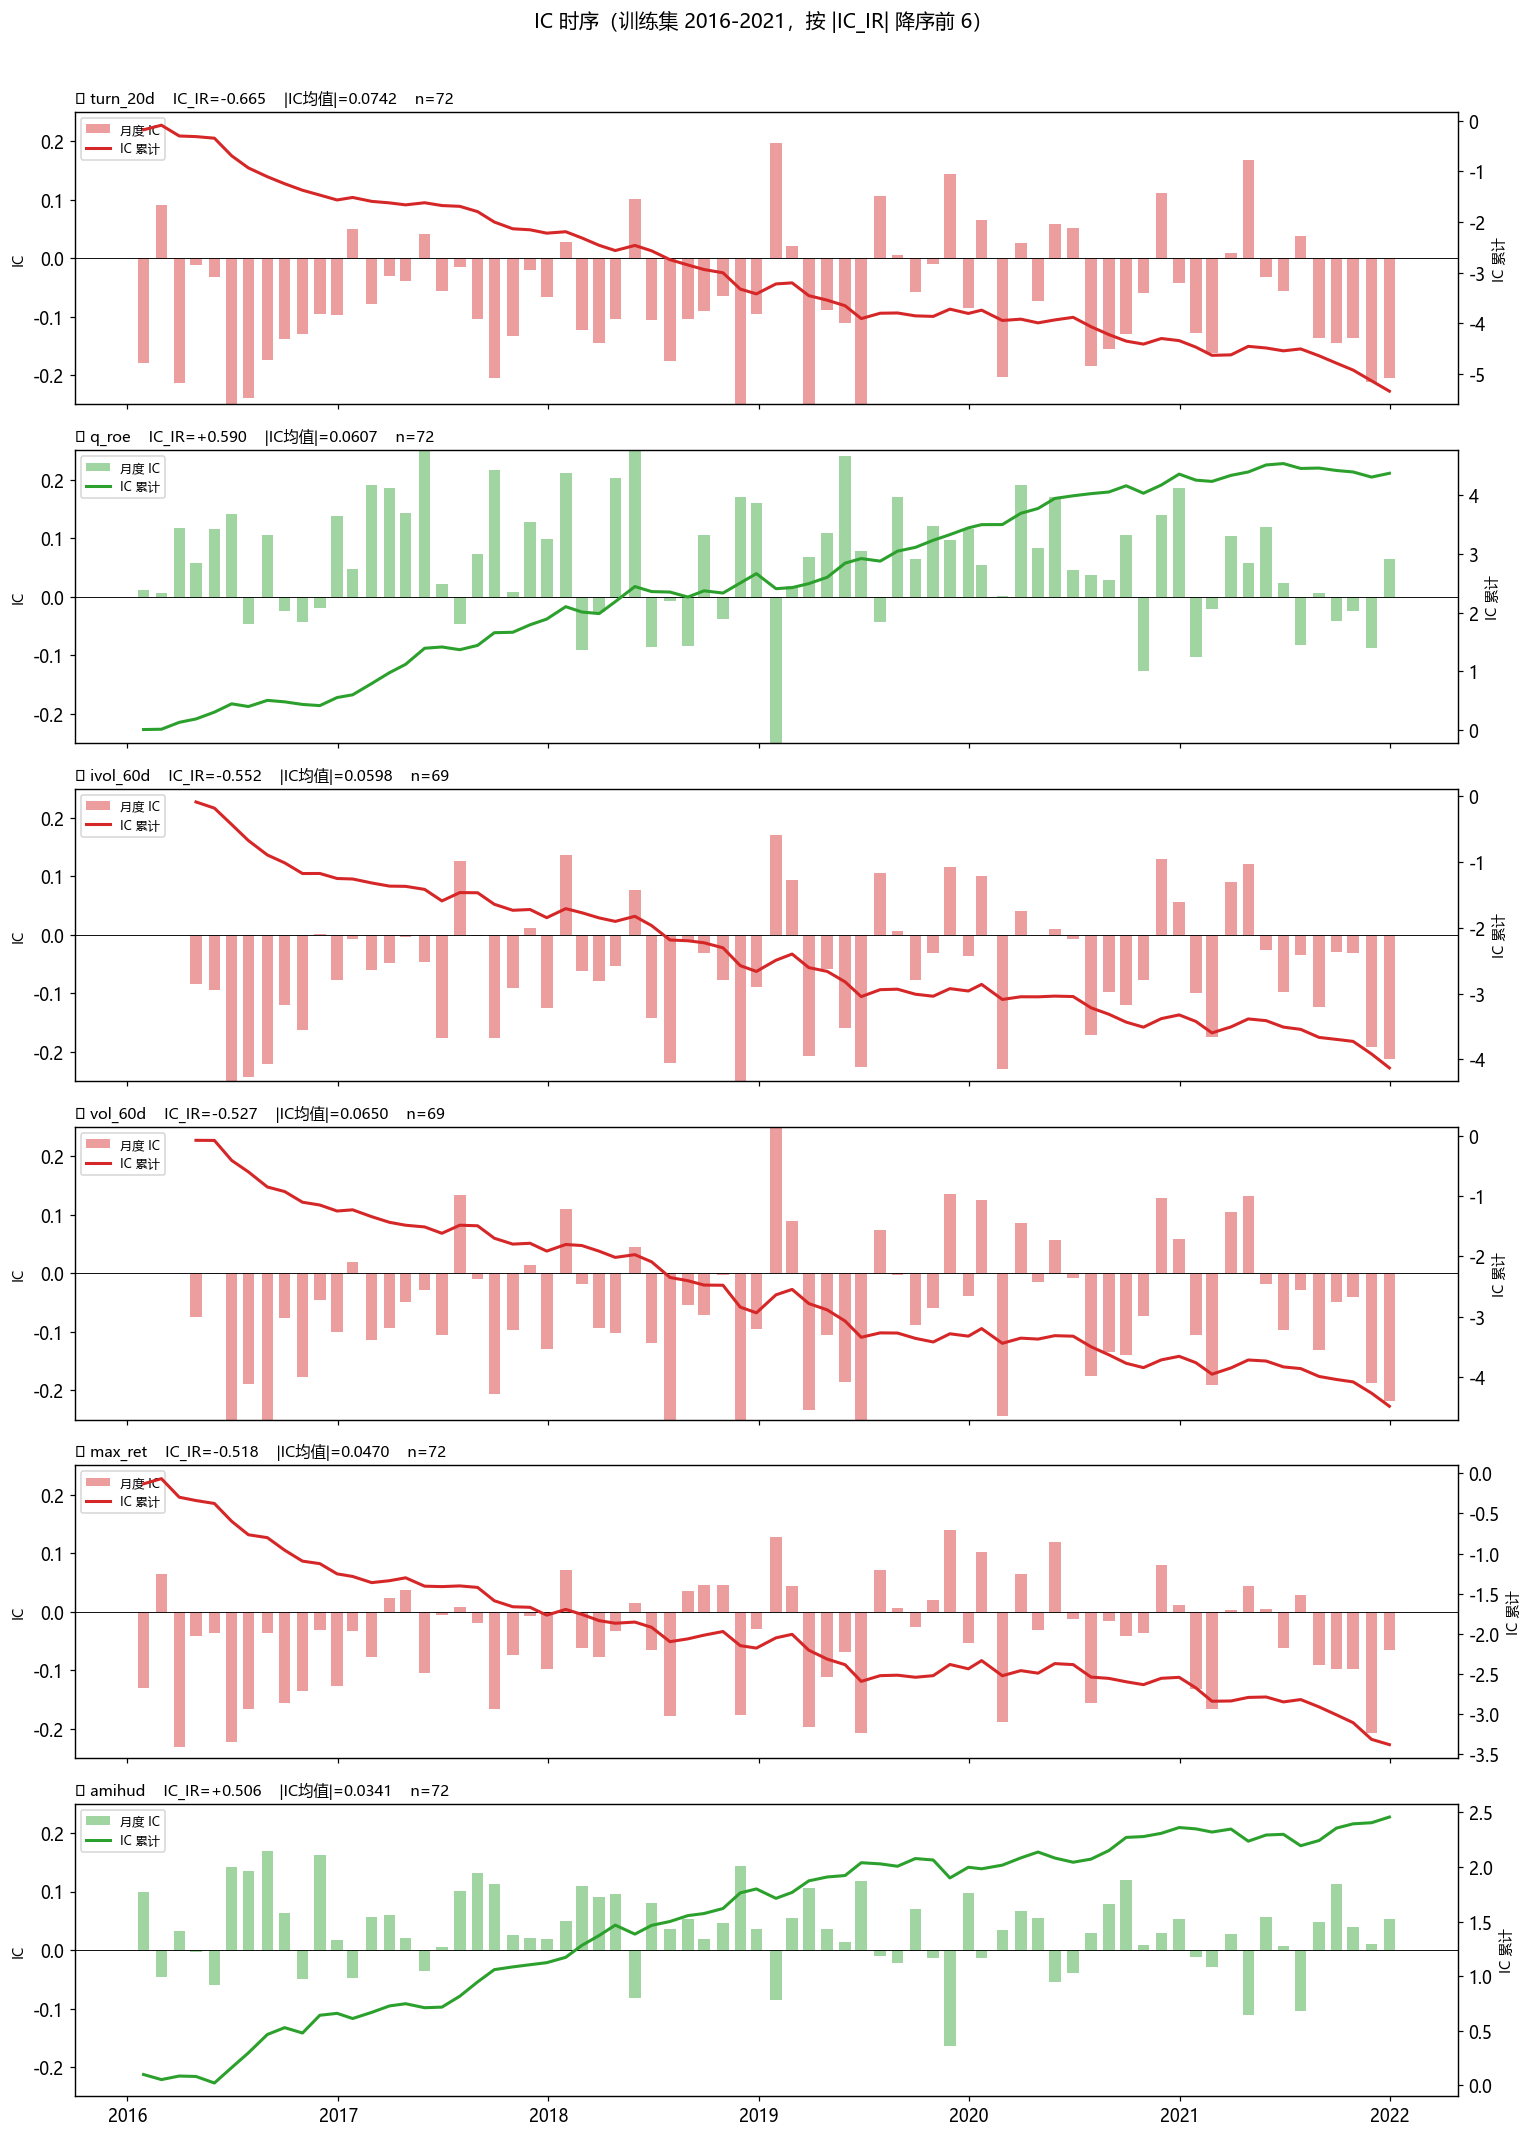

In [8]:
n_plot = min(6, len(ic_result))
plot_factors = ic_result.head(n_plot).index.tolist()

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3.2 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for ax, fname in zip(axes, plot_factors):
    ic_s    = compute_ic_series(train_panels[fname], train_fwd)
    ic_cum  = ic_s.cumsum()
    ic_mean = ic_result.loc[fname, "ic_mean"]
    ic_ir   = ic_result.loc[fname, "ic_ir"]
    is_eff  = ic_result.loc[fname, "effective"]

    # 正向因子用绿色，负向用红色
    bar_color = "#2ca02c" if ic_mean >= 0 else "#d62728"

    ax.bar(ic_s.index, ic_s.values, color=bar_color, alpha=0.45, width=20, label="月度 IC")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("IC", fontsize=9)
    ax.set_ylim(-0.25, 0.25)

    ax2 = ax.twinx()
    ax2.plot(ic_cum.index, ic_cum.values, color=bar_color, linewidth=2, label="IC 累计")
    ax2.set_ylabel("IC 累计", fontsize=9)

    eff_mark = "✅" if is_eff else "❌"
    ax.set_title(
        f"{eff_mark} {fname}    IC_IR={ic_ir:+.3f}    "
        f"|IC均值|={abs(ic_mean):.4f}    n={int(ic_result.loc[fname,'n'])}",
        fontsize=10, loc="left"
    )

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

fig.suptitle("IC 时序（训练集 2016-2021，按 |IC_IR| 降序前 6）", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_ic_timeseries_top6.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 5 分组等权回测

每期将股票按因子值等频分为 5 组（Q1 最低、Q5 最高），等权持有至下期。  
**不含交易成本**，用于验证因子方向性而非精确测算超额收益。  
DirectionalLS Sharpe（按训练集 IC 方向调整后的年化多空 Sharpe）是因子区分度的核心指标；原始 Q5-Q1 仍保留用于检查分组单调性。

In [9]:
print("分组回测中（约 30-60 秒）...")
quintile_summary = batch_quintile_summary(train_panels, train_fwd)
print("分组回测完成")

quintile_summary.style \
    .background_gradient(subset=["directional_sharpe_ls"], cmap="RdYlGn", vmin=-1, vmax=2) \
    .format({
        "factor_direction": "{:+.0f}",
        "q1_ann_ret": "{:+.2%}",
        "q5_ann_ret": "{:+.2%}",
        "ls_ann_ret": "{:+.2%}",
        "directional_ls_ann_ret": "{:+.2%}",
        "sharpe_ls":  "{:.2f}",
        "directional_sharpe_ls":  "{:.2f}",
    })

分组回测中（约 30-60 秒）...


分组回测完成


,n_periods,factor_direction,q1_ann_ret,q5_ann_ret,ls_ann_ret,directional_ls_ann_ret,sharpe_ls,directional_sharpe_ls
factor,,,,,,,,
q_roe,72,+1,+0.02%,+16.15%,+16.13%,+16.13%,1.54,1.54
np_yoy,72,+1,-0.41%,+13.07%,+13.48%,+13.48%,1.45,1.45
roe_delta,72,+1,+0.36%,+13.27%,+12.91%,+12.91%,1.43,1.43
margin_ratio,72,-1,+14.88%,+2.10%,-12.78%,+12.78%,-1.28,1.28
rev_yoy,72,+1,+0.78%,+9.78%,+9.00%,+9.00%,1.26,1.26
roe,72,+1,+1.35%,+13.50%,+12.15%,+12.15%,1.23,1.23
roa,72,+1,+2.05%,+13.93%,+11.88%,+11.88%,1.19,1.19
holder_chg,72,+1,+3.65%,+11.64%,+8.00%,+8.00%,1.16,1.16
mom_12_1,61,+1,-3.35%,+11.82%,+15.17%,+15.17%,1.11,1.11


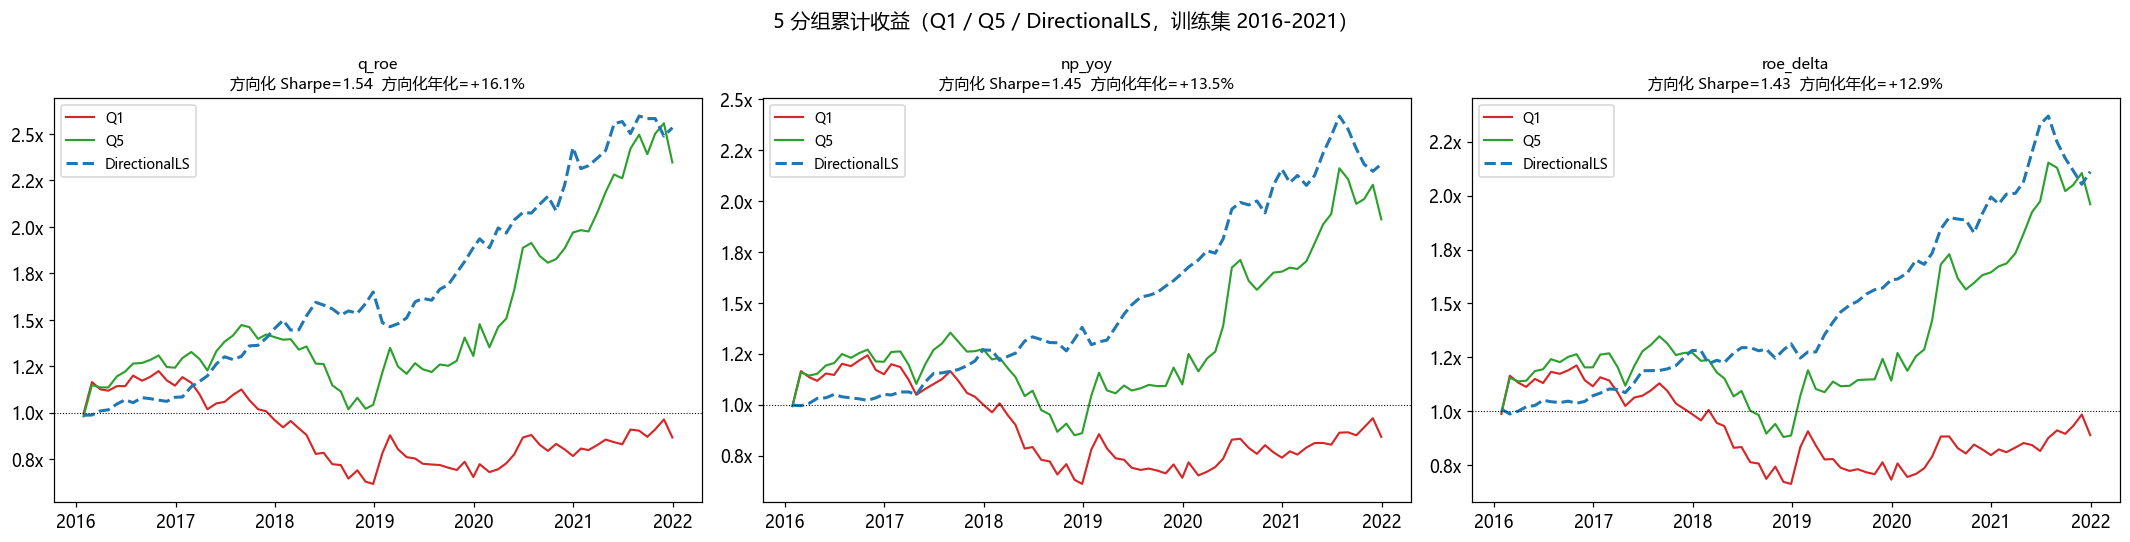

In [10]:
# 绘制多空 Sharpe 最高的前 3 因子的累计收益曲线
top3 = quintile_summary.dropna(subset=["directional_sharpe_ls"]).head(3).index.tolist()

fig, axes = plt.subplots(1, len(top3), figsize=(6.5 * len(top3), 5), sharey=False)
if len(top3) == 1:
    axes = [axes]

for ax, fname in zip(axes, top3):
    direction = quintile_summary.loc[fname, "factor_direction"]
    res = run_quintile_backtest(train_panels[fname], train_fwd, direction=direction)
    cum = res.get("cum_rets", pd.DataFrame())
    if cum.empty:
        ax.set_title(f"{fname} — 无有效数据")
        continue

    for col in ["Q1", "Q5", "DirectionalLS"]:
        if col in cum.columns:
            ax.plot(
                cum.index, cum[col],
                label=col,
                color=COLORS.get(col, "gray"),
                linewidth=2.0 if col == "DirectionalLS" else 1.4,
                linestyle="--" if col == "DirectionalLS" else "-",
            )

    ax.axhline(1.0, color="black", linewidth=0.7, linestyle=":")
    ax.set_title(
        f"{fname}\n方向化 Sharpe={quintile_summary.loc[fname,'directional_sharpe_ls']:.2f}  "
        f"方向化年化={quintile_summary.loc[fname,'directional_ls_ann_ret']:+.1%}",
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax.set_xlabel("")

fig.suptitle("5 分组累计收益（Q1 / Q5 / DirectionalLS，训练集 2016-2021）", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_quintile_cumret_top3.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 因子相关性矩阵

计算各因子横截面 Spearman Rank 相关系数的时间均值。

**判断标准**：
- `|r| > 0.7`：高度相关，存在信息冗余，考虑去掉其中 IC_IR 较低的一个
- `|r| > 0.9`：几乎线性相关，保留一个即可

IC_IR 加权合成时，高相关因子对会重复计数同一风险敞口，导致组合实际暴露失衡。

计算因子相关性矩阵（约 10-20 秒）...


相关矩阵形状：(27, 27)


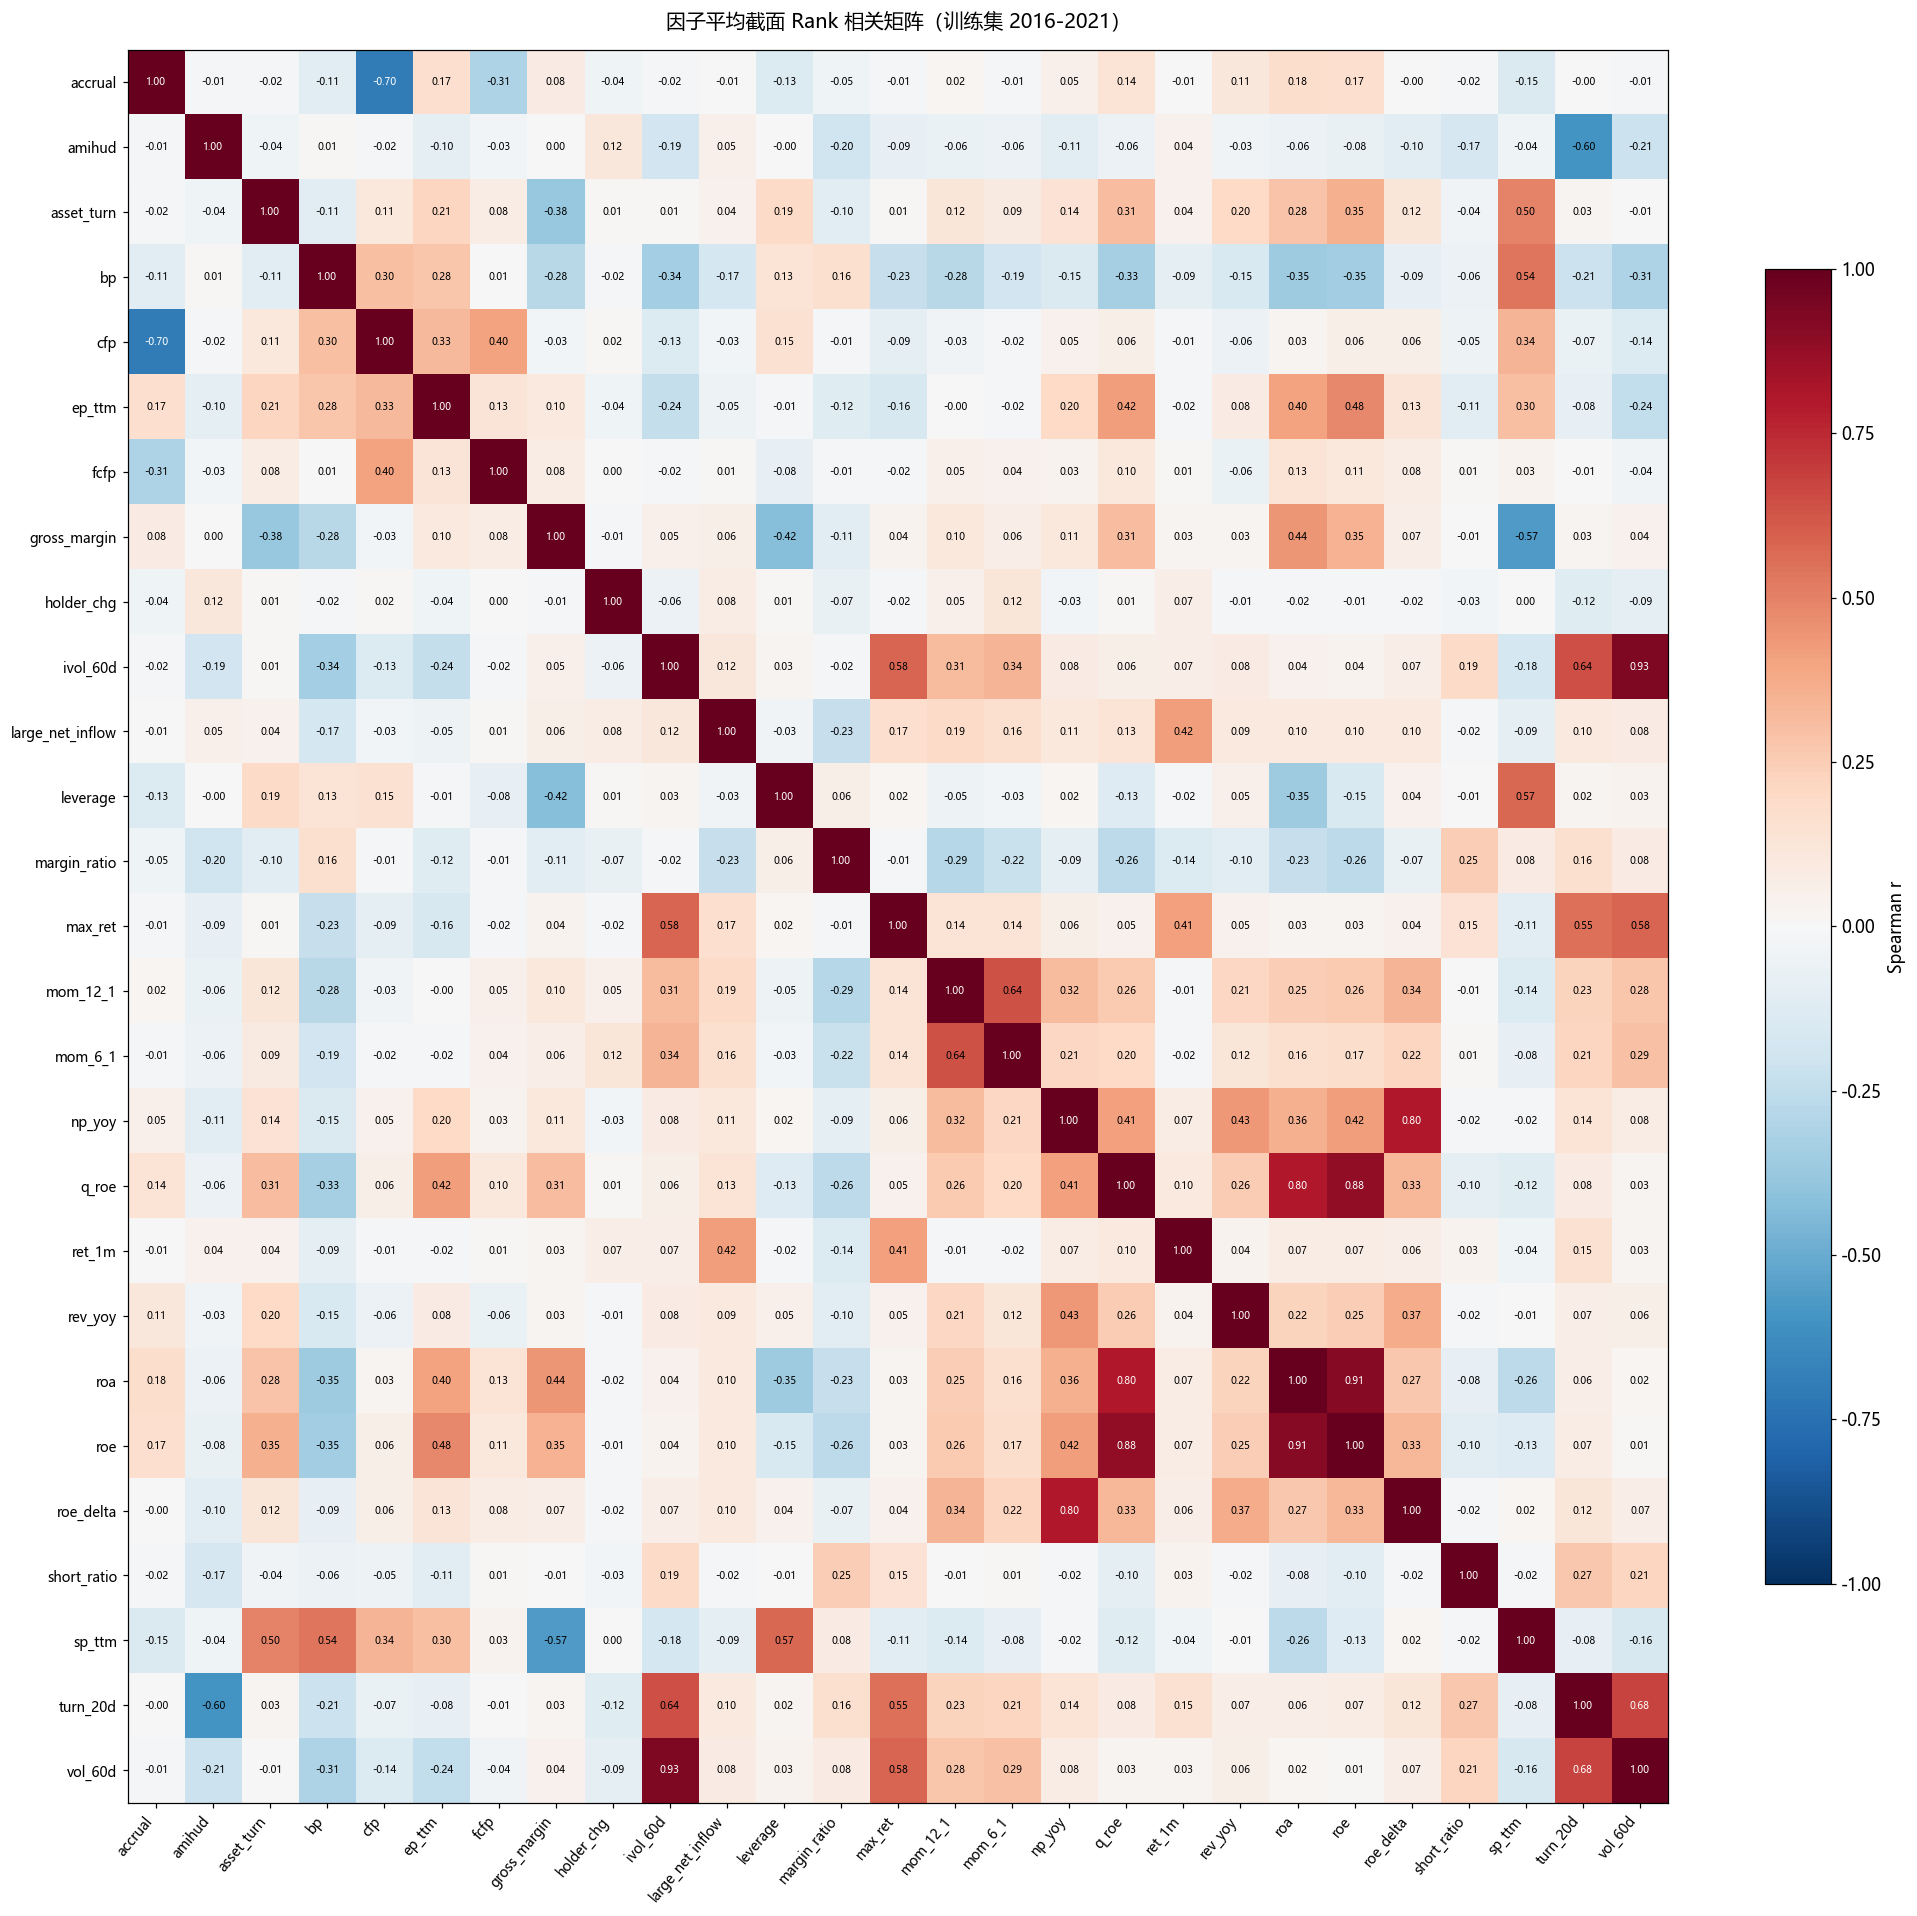


⚠️  高相关因子对（|r| > 0.7）：
   因子 A                  因子 B                       r  建议去掉
   ivol_60d              vol_60d               +0.934  vol_60d
   roa                   roe                   +0.909  roe
   q_roe                 roe                   +0.885  roe
   np_yoy                roe_delta             +0.805  roe_delta
   q_roe                 roa                   +0.802  roa
   accrual               cfp                   -0.701  accrual


In [11]:
print("计算因子相关性矩阵（约 10-20 秒）...")
corr_matrix = compute_factor_correlation(train_panels)
print(f"相关矩阵形状：{corr_matrix.shape}")

factor_labels = corr_matrix.columns.tolist()
n_f = len(factor_labels)

fig, ax = plt.subplots(figsize=(max(12, n_f * 0.7), max(10, n_f * 0.65)))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.75, label="Spearman r")

ax.set_xticks(range(n_f))
ax.set_yticks(range(n_f))
ax.set_xticklabels(factor_labels, rotation=50, ha="right", fontsize=9)
ax.set_yticklabels(factor_labels, fontsize=9)

for i in range(n_f):
    for j in range(n_f):
        val = corr_matrix.iloc[i, j]
        if pd.notna(val):
            txt_color = "white" if abs(val) > 0.65 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6.5, color=txt_color)

ax.set_title("因子平均截面 Rank 相关矩阵（训练集 2016-2021）", fontsize=13, pad=15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_factor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# 输出高相关因子对
HIGH_CORR_THRESHOLD = 0.70
high_corr_pairs = []
for i, row_f in enumerate(factor_labels):
    for j, col_f in enumerate(factor_labels):
        if j <= i:
            continue
        v = corr_matrix.loc[row_f, col_f]
        if pd.notna(v) and abs(v) > HIGH_CORR_THRESHOLD:
            # 找出两者中 IC_IR 较低的那个（建议去掉）
            ir_row = ic_result.loc[row_f, "ic_ir"] if row_f in ic_result.index else float("nan")
            ir_col = ic_result.loc[col_f, "ic_ir"] if col_f in ic_result.index else float("nan")
            weaker = col_f if abs(ir_row) >= abs(ir_col) else row_f
            high_corr_pairs.append((row_f, col_f, v, weaker))

if high_corr_pairs:
    print(f"\n⚠️  高相关因子对（|r| > {HIGH_CORR_THRESHOLD}）：")
    print(f"   {'因子 A':20s}  {'因子 B':20s}  {'r':>6}  建议去掉")
    for a, b, r, weaker in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"   {a:20s}  {b:20s}  {r:+.3f}  {weaker}")
else:
    print(f"\n✅ 无高相关因子对（所有 |r| ≤ {HIGH_CORR_THRESHOLD}）")

## 9. 验证集稳健性确认（2022）

⚠️ **注意**：验证集仅 ~11 个有效期（最后一期 forward return 为 NaN），统计检验力不足。  
本节结论**不用于因子选择**，只用于排查训练期严重过拟合或方向翻转的因子。

关注点：
- 训练集有效、验证集 IC_IR 方向翻转 → 可能是训练期特殊市场环境导致的伪因子
- 训练集有效、验证集 IC_IR 仍同向但变小 → 正常衰减，可接受

In [12]:
print(f"验证集期数：{len(valid_dates)}（forward return 有效期约 {len(valid_fwd)} 期）")
print("验证集 IC 检验中...")
valid_ic = batch_ic_test(valid_panels, valid_fwd)

# 拼合训练 vs 验证 IC_IR 对比
comparison = pd.DataFrame({
    "train_n":       ic_result["n"],
    "train_ic_ir":   ic_result["ic_ir"],
    "valid_n":       valid_ic["n"],
    "valid_ic_ir":   valid_ic["ic_ir"],
    "train_effective": ic_result["effective"],
}).sort_values("train_ic_ir", key=abs, ascending=False)

# 方向翻转：训练集与验证集 IC_IR 符号相反
comparison["direction_flip"] = (
    comparison["train_ic_ir"] * comparison["valid_ic_ir"]
) < 0

flipped = comparison[comparison["direction_flip"]].index.tolist()
if flipped:
    print(f"\n⚠️  验证集 IC_IR 方向翻转（需关注）：")
    for f in flipped:
        r = comparison.loc[f]
        print(f"   {f:20s}  训练={r['train_ic_ir']:+.3f} → 验证={r['valid_ic_ir']:+.3f}")
else:
    print("\n✅ 所有因子在验证集方向一致（无翻转）")

comparison.style \
    .background_gradient(subset=["train_ic_ir", "valid_ic_ir"], cmap="RdYlGn", vmin=-1, vmax=1) \
    .map(lambda v: "background-color: #fff3cd" if v else "", subset=["direction_flip"]) \
    .format({
        "train_ic_ir": "{:+.3f}",
        "valid_ic_ir": "{:+.3f}",
    })

验证集期数：12（forward return 有效期约 11 期）
验证集 IC 检验中...



⚠️  验证集 IC_IR 方向翻转（需关注）：
   q_roe                 训练=+0.590 → 验证=-0.182
   roa                   训练=+0.501 → 验证=-0.315
   roe                   训练=+0.500 → 验证=-0.229
   ep_ttm                训练=+0.499 → 验证=-0.049
   np_yoy                训练=+0.465 → 验证=-0.144
   roe_delta             训练=+0.435 → 验证=-0.018
   asset_turn            训练=+0.388 → 验证=-0.308
   gross_margin          训练=+0.357 → 验证=-0.150
   mom_6_1               训练=+0.247 → 验证=-0.277
   leverage              训练=-0.084 → 验证=+0.130


,train_n,train_ic_ir,valid_n,valid_ic_ir,train_effective,direction_flip
factor,,,,,,
turn_20d,72,-0.665,11,-0.727,True,False
q_roe,72,+0.590,11,-0.182,True,True
ivol_60d,69,-0.552,11,-0.738,True,False
vol_60d,69,-0.527,11,-0.437,True,False
max_ret,72,-0.518,11,-0.706,True,False
amihud,72,+0.506,11,+0.375,True,False
holder_chg,72,+0.502,11,+0.004,True,False
roa,72,+0.501,11,-0.315,True,True
roe,72,+0.500,11,-0.229,True,True


## 10. 汇总报告

综合所有检验结果，输出最终有效因子清单，供后续信号合成（`signal/combiner.py`）使用。

In [13]:
# 合并所有维度的评估结果
summary = pd.DataFrame(index=ic_result.index)
summary["ic_ir"]          = ic_result["ic_ir"]
summary["ic_mean"]        = ic_result["ic_mean"]
summary["ic_n"]           = ic_result["n"].astype(int)
summary["p_value_bh"]     = ic_result["p_value_bh"]
summary["effective_ic"]   = ic_result["effective"]
summary["shift_drop"]     = shift_result.reindex(summary.index)["ic_ir_drop"]
summary["shift_warning"]  = shift_result.reindex(summary.index)["warning"]
summary["factor_direction"] = quintile_summary.reindex(summary.index)["factor_direction"]
summary["sharpe_ls"]      = quintile_summary.reindex(summary.index)["sharpe_ls"]
summary["directional_sharpe_ls"] = quintile_summary.reindex(summary.index)["directional_sharpe_ls"]
summary["dir_flip_valid"] = comparison.reindex(summary.index)["direction_flip"]

# 最终综合判断：IC 有效 + 无错位警告
summary["final_include"] = summary["effective_ic"] & ~summary["shift_warning"].fillna(False)

# 打印报告
print("=" * 65)
print("因子有效性检验汇总报告（训练集 2016-2021）")
print("=" * 65)

final_factors = summary[summary["final_include"]].index.tolist()
excluded      = summary[~summary["final_include"]].index.tolist()

print(f"\n✅ 最终纳入合成的因子（{len(final_factors)} 个）：")
for f in final_factors:
    row = summary.loc[f]
    flip = " ⚠️方向翻转" if row.get("dir_flip_valid") else ""
    sharpe = f"DirSharpe={row['directional_sharpe_ls']:.2f}" if pd.notna(row["directional_sharpe_ls"]) else "DirSharpe=N/A"
    print(f"   {f:20s}  IC_IR={row['ic_ir']:+.3f}  {sharpe}{flip}")

print(f"\n❌ 排除因子（{len(excluded)} 个）：{excluded}")

print("\n" + "-" * 65)
print("下一步：")
print("  1. 检查高相关因子对（第 8 节），必要时从 final_factors 中删除冗余因子")
print("  2. 将 final_factors 传入 signal/combiner.build_composite_panel(method='ic_ir')")
print("  3. 计算合成信号面板（scripts/build_composite_signal.py，下一步待实现）")

print("\n汇总表（按 |IC_IR| 降序）：")
summary.sort_values("ic_ir", key=abs, ascending=False).style \
    .background_gradient(subset=["ic_ir"], cmap="RdYlGn", vmin=-1, vmax=1) \
    .map(lambda v: "font-weight: bold; color: #2ca02c" if v else "color: #aaa",
               subset=["final_include"]) \
    .format({
        "ic_ir":       "{:+.3f}",
        "ic_mean":     "{:+.4f}",
        "p_value_bh":  "{:.4f}",
        "shift_drop":  "{:+.3f}",
        "factor_direction": "{:+.0f}",
        "sharpe_ls":   "{:.2f}",
        "directional_sharpe_ls":   "{:.2f}",
    }, na_rep="N/A")

因子有效性检验汇总报告（训练集 2016-2021）

✅ 最终纳入合成的因子（18 个）：
   turn_20d              IC_IR=-0.665  DirSharpe=0.86
   q_roe                 IC_IR=+0.590  DirSharpe=1.54 ⚠️方向翻转
   ivol_60d              IC_IR=-0.552  DirSharpe=0.58
   vol_60d               IC_IR=-0.527  DirSharpe=0.58
   max_ret               IC_IR=-0.518  DirSharpe=0.38
   amihud                IC_IR=+0.506  DirSharpe=0.64
   holder_chg            IC_IR=+0.502  DirSharpe=1.16
   roa                   IC_IR=+0.501  DirSharpe=1.19 ⚠️方向翻转
   roe                   IC_IR=+0.500  DirSharpe=1.23 ⚠️方向翻转
   ep_ttm                IC_IR=+0.499  DirSharpe=1.03 ⚠️方向翻转
   rev_yoy               IC_IR=+0.467  DirSharpe=1.26
   np_yoy                IC_IR=+0.465  DirSharpe=1.45 ⚠️方向翻转
   roe_delta             IC_IR=+0.435  DirSharpe=1.43 ⚠️方向翻转
   cfp                   IC_IR=+0.426  DirSharpe=0.97
   margin_ratio          IC_IR=-0.401  DirSharpe=1.28
   asset_turn            IC_IR=+0.388  DirSharpe=0.94 ⚠️方向翻转
   short_ratio           IC_IR=-0.378  D

,ic_ir,ic_mean,ic_n,p_value_bh,effective_ic,shift_drop,shift_warning,factor_direction,sharpe_ls,directional_sharpe_ls,dir_flip_valid,final_include
factor,,,,,,,,,,,,
turn_20d,-0.665,-0.0742,72,0.0000,True,+0.081,False,-1,-0.86,0.86,False,True
q_roe,+0.590,+0.0607,72,0.0001,True,+0.135,False,+1,1.54,1.54,True,True
ivol_60d,-0.552,-0.0598,69,0.0002,True,+0.093,False,-1,-0.58,0.58,False,True
vol_60d,-0.527,-0.0650,69,0.0002,True,+0.038,False,-1,-0.58,0.58,False,True
max_ret,-0.518,-0.0470,72,0.0002,True,+0.128,False,-1,-0.38,0.38,False,True
amihud,+0.506,+0.0341,72,0.0002,True,+0.063,False,+1,0.64,0.64,False,True
holder_chg,+0.502,+0.0317,72,0.0002,True,+0.024,False,+1,1.16,1.16,False,True
roa,+0.501,+0.0481,72,0.0002,True,+0.055,False,+1,1.19,1.19,True,True
roe,+0.500,+0.0513,72,0.0002,True,+0.063,False,+1,1.23,1.23,True,True


In [14]:
# ===== 导出所有分析结果 =====
# 将文字表格保存为 CSV，生成 Markdown 汇总报告，便于 AI 协助分析

# --- 5.1 CSV 导出 ---
overview.to_csv(OUTPUT_DIR / "factor_overview.csv")
ic_result.to_csv(OUTPUT_DIR / "ic_result.csv")
shift_result.to_csv(OUTPUT_DIR / "shift_result.csv")
quintile_summary.to_csv(OUTPUT_DIR / "quintile_summary.csv")
corr_matrix.to_csv(OUTPUT_DIR / "factor_correlation.csv")
comparison.to_csv(OUTPUT_DIR / "valid_comparison.csv")
summary.sort_values("ic_ir", key=abs, ascending=False).to_csv(OUTPUT_DIR / "factor_summary.csv")

# --- 5.2 Markdown 汇总报告 ---
lines = []
lines.append("# 因子有效性检验报告（02_factor_evaluation）")
lines.append(f"\n生成时间：{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
lines.append(f"\n训练集：{train_dates[0].date()} ~ {train_dates[-1].date()}（{len(train_dates)} 期）")
lines.append(f"\n验证集：{valid_dates[0].date()} ~ {valid_dates[-1].date()}（{len(valid_dates)} 期）")

lines.append("\n\n---\n\n## 1. 因子面板概览\n")
lines.append(overview.to_markdown())

lines.append("\n\n---\n\n## 2. IC 检验结果（训练集）\n")
lines.append(ic_result[display_cols].round(4).to_markdown(floatfmt=".4f"))
lines.append(f"\n\n✅ **有效因子（{len(effective_factors)} 个）**：")
for f in effective_factors:
    row = ic_result.loc[f]
    lines.append(f"\n- `{f}` IC_IR={row['ic_ir']:+.3f}  |IC均值|={abs(row['ic_mean']):.4f}  p_bh={row['p_value_bh']:.4f}")
lines.append(f"\n\n❌ **未通过（{len(invalid_factors)} 个）**：`{'`、`'.join(invalid_factors)}`")

lines.append("\n\n---\n\n## 3. 时间错位测试\n")
lines.append(shift_result.round(3).to_markdown(floatfmt=".3f"))
if warned_factors:
    lines.append(f"\n\n⚠️ **警告因子**：`{'`、`'.join(warned_factors)}`")
else:
    lines.append("\n\n✅ 所有因子时间错位测试正常（无未来函数疑点）")

lines.append("\n\n---\n\n## 4. 5分组回测摘要（训练集，不含成本）\n")
lines.append(quintile_summary.round(4).to_markdown(floatfmt=".4f"))

lines.append("\n\n---\n\n## 5. 因子相关性（高相关对）\n")
if high_corr_pairs:
    lines.append("| 因子A | 因子B | Spearman r | 建议去掉 |")
    lines.append("|------|------|-----------|---------|")
    for a, b, r, weaker in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        lines.append(f"| `{a}` | `{b}` | {r:+.3f} | `{weaker}` |")
else:
    lines.append(f"✅ 无高相关因子对（所有 |r| ≤ {HIGH_CORR_THRESHOLD}）")

lines.append("\n\n---\n\n## 6. 验证集稳健性（2022）\n")
lines.append(comparison.round(3).to_markdown(floatfmt=".3f"))
if flipped:
    lines.append(f"\n\n⚠️ **方向翻转因子（需关注）**：`{'`、`'.join(flipped)}`")
else:
    lines.append("\n\n✅ 所有因子在验证集方向一致（无翻转）")

lines.append("\n\n---\n\n## 7. 最终因子汇总\n")
lines.append(summary.sort_values("ic_ir", key=abs, ascending=False).round(3).to_markdown(floatfmt=".3f"))
lines.append(f"\n\n### 最终纳入合成：{len(final_factors)} 个")
for f in final_factors:
    row = summary.loc[f]
    flip = " ⚠️方向翻转" if row.get("dir_flip_valid") else ""
    sharpe = f"{row['directional_sharpe_ls']:.2f}" if pd.notna(row["directional_sharpe_ls"]) else "N/A"
    lines.append(f"\n- `{f}` IC_IR={row['ic_ir']:+.3f}  Directional_Sharpe_LS={sharpe}{flip}")
lines.append(f"\n\n### 排除：{len(excluded)} 个")
lines.append(f"\n`{'`、`'.join(excluded)}`")

lines.append("\n\n---\n\n## 图表文件")
lines.append("\n- `01_ic_timeseries_top6.png`：前6因子月度IC时序 + 累计IC")
lines.append("\n- `02_quintile_cumret_top3.png`：方向化多空Sharpe最高前3因子5分组累计收益")
lines.append("\n- `03_factor_correlation.png`：因子截面Rank相关性热力图")

report_path = OUTPUT_DIR / "factor_evaluation_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")

print(f"✅ 报告已生成：{report_path}")
print(f"\n📁 导出文件清单（{OUTPUT_DIR}）：")
for p in sorted(OUTPUT_DIR.iterdir()):
    size = p.stat().st_size
    print(f"   {p.name:50s} {size:>8,} bytes")


✅ 报告已生成：E:\Acoding\Project\500\reports\factor_evaluation\factor_evaluation_report.md

📁 导出文件清单（E:\Acoding\Project\500\reports\factor_evaluation）：
   01_ic_timeseries_top6.png                           324,276 bytes
   02_quintile_cumret_top3.png                         238,174 bytes
   03_factor_correlation.png                           529,830 bytes
   factor_correlation.csv                               14,939 bytes
   factor_evaluation_report.md                          27,447 bytes
   factor_overview.csv                                   1,342 bytes
   factor_summary.csv                                    3,573 bytes
   final_factors.json                                      784 bytes
   ic_result.csv                                         2,613 bytes
   quintile_summary.csv                                  3,800 bytes
   seg_ic_ir.csv                                           826 bytes
   shift_result.csv                                      1,325 bytes
   valid_comparison.csv   